In [1]:
env_USE_GOOGLE_COLAB = False
env_USE_NVIDIA = False
env_CONTENT_PATH = ""
env_TIF_PATH = ""
env_WANT_NGROK = False
env_Latest_RUN_ID = 0
import sys
from settings import load_BatGutsSettings, show_python_version, corr2, get_most_recent_subdirectory, get_most_recent_numeric_subdirectory
from settings import run_mlflow_until_q
show_python_version()

S = load_BatGutsSettings()
env_CONTENT_PATH = S.zContentPath
env_TIF_PATH = S.zTifPath
env_USE_GOOGLE_COLAB = S.useGoogleColab
env_USE_NVIDIA = S.useNvidia
env_MODEL_FILENAME = S.zModelFilename
env_FULL_MODEL_PATH = env_CONTENT_PATH + "/" + env_MODEL_FILENAME
#We use the settings module to load the settings from the .env file for running this program


Python version: 3.10.12
Loading settings from /home/elliot/BatGutsImageClassification2/jupyternb/.env
my_CONTENT_PATH=/home/elliot/BatGutsImageClassification2/
my_TIF_PATH=/mnt/d/


In [2]:
#this is for setting the model to use CPU only
#if you want to try and use CUDA thats fine just dont run this cell
#i will warn you though it is really annoying

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disable GPU usage
os.environ["TF_FORCE_UNIFIED_MEMORY"] = "1"  # Fix NUMA-related issues
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"  # Disable XLA
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Disable OneDNN optimizations

# Disable all GPUs
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

# Verify that only the CPU is being used
print("Available devices:", tf.config.list_physical_devices('CPU'))



2025-02-11 17:36:29.914739: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-11 17:36:29.931983: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-11 17:36:29.937806: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-11 17:36:29.950630: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-11 17:36:30.770267: W tensorflow/com

Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-02-11 17:36:32.409553: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:
import numpy as np
from matplotlib import pyplot as plt
import tifffile as tiff
from pyngrok import ngrok
import numpy as np
from PIL import Image as im
from PIL import  ImageOps
import numpy as np
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
from tensorflow.python.keras.utils.data_utils import Sequence
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
import mlflow
''' 
this cell sets up a clean environment for MLflow tracking:
It removes any existing MLflow runs directory (if it exists).
It creates a fresh directory for new MLflow runs.
It configures MLflow to use this new directory for tracking experiments and runs.
This approach ensures that MLflow starts with a clean slate, which can be useful for avoiding conflicts with 
previous runs or for maintaining a consistent environment across different executions of a machine learning workflow.
'''
zUrl = env_CONTENT_PATH + "/mlruns/"
if os.path.exists(zUrl):
    shutil.rmtree(zUrl)    #r removes the entire directory tree 
    print(f"Deleted directory: {zUrl}")
os.makedirs(zUrl, exist_ok=True)
mlflow.set_tracking_uri(zUrl)   # sets the tracking URI for MLflow to the newly created directory 
EXPERIMENT_NAME = "Batguts-Insects_vs_plants_Siamese_256"
EXPERIMENT_ID = mlflow.create_experiment(EXPERIMENT_NAME)
#sets up mlflow to track the experiment, not really necessary for us right now but good to have
import seaborn as sns
import cv2
import time
import os
import glob

Deleted directory: /home/elliot/BatGutsImageClassification2//mlruns/


In [4]:
''' 
Standardizes each image in the list:
It subtracts the mean (mean_img)
Then divides by the standard deviation (std_img)
This process centers the pixel values around 0 and scales them to have unit variance.
'''
def standardize_image(img_list):
  mean_img = np.mean(img_list,axis=0)  # calculates the mean value across all images in the list
  std_img = np.std(img_list,axis=0)   # calculates the standard deviation across all images in the list,
  img_list = (img_list - mean_img)/std_img
  return img_list

#standardizing the images is important because it makes it easier for the CNN to learn from
#the standardization makes the pixel values more consistent across the dataset, so slight differences dont throw the model off


In [5]:
''' 
This function loads images from a specific category and creates corresponding image and label lists.
'''
def train_imgs(img_list=None, category=None, label_list=None):
    if img_list is None:
        img_list = []
    if label_list is None:
        label_list = []
    #setup image/label list

    category_path = os.path.join(env_CONTENT_PATH, "images/Bats_mixed_images_RGB_256", str(category))
    #get path for given category

    # check if category path exists
    if not os.path.exists(category_path):
        print(f"Warning: Category '{category}' does not exist. Skipping...")
        return img_list, label_list  # Ensure function always returns a tuple

    # get list of images
    image_paths = glob.glob(os.path.join(category_path, "*.jpeg"))
    print('{} Images Count: {}'.format(category, len(image_paths)))

    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is not None:  # Ensure the image was read correctly
            img_list.append(image)
            label_list.append(category)
    #iterate through images, add them to the lists

    return img_list, label_list  # Ensure function always returns a tuple

In [6]:
#prepare training data
train_imgs_list = list()
labels_list =list()
# train_imgs_list,labels_list=train_imgs(train_imgs_list,'Blood',labels_list)
train_imgs_list,labels_list=train_imgs(train_imgs_list,'Insects',labels_list)
#get initial list of insect images
train_imgs_list,labels_list=train_imgs(train_imgs_list,'Plants',labels_list)
#run it again with previous list to add plant images

Insects Images Count: 168
Plants Images Count: 241


In [7]:
from sklearn.preprocessing import LabelEncoder
labels_list= LabelEncoder().fit_transform(labels_list)
#encodes the labels as integers, 1 for plants, 0 for insects.
#this makes it easier for the model to understand the labels
from collections import Counter
Counter(labels_list)

Counter({1: 241, 0: 168})

In [8]:
#Shuffle the data
import random

temp = list(zip(train_imgs_list, labels_list))
#combine the images+labels using zip, then convert to a list
random.shuffle(temp)
#randomly shuffle the list of images+label pairs
train_imgs_list,labels_list = zip(*temp)
#extract the images and labels back into separate lists
train_imgs_list,labels_list = list(train_imgs_list), list(labels_list)
#convert the zip objects back into lists

In [9]:
'''
This code performs two important preprocessing steps on a list of images, typically in preparation for training a 
machine learning model, particularly a neural network.  

First it converts train_imgs_list to a NumPy array with data type float32.
Then it Divides the array by 255.0.
This normalizes the pixel values of the images to a range between 0 and 1.
Normalization is important because:
  It helps achieve faster convergence during model training.
  It ensures all features (pixel values) are on a similar scale, which is crucial for many machine learning algorithms.
  
Then it calls the standardize_image function on the normalized image array.
Standardization typically involves subtracting the mean and dividing by the standard deviation.
This centers the data around zero and scales it to have unit variance.
Benefits of standardization include:
  Making training less sensitive to the scale of features.
  Improving the numerical stability of some machine learning algorithms.
'''
X = np.array(train_imgs_list,np.float32)/255.0
X = standardize_image(X)

In [10]:
''' 
This cell converts a Python list called labels_list into a NumPy array

Converting labels_list to a NumPy array makes it more efficient and provides 
access to a wide range of functionalities for numerical and data manipulation tasks. This step is 
often a part of data preprocessing in machine learning workflows.
'''
labels_list = np.array(labels_list)

In [11]:
num_classes = 2
def one_hot_labels(img_list,classes):


  # label_numeric = {k:v for v,k in enumerate(set(img_list))} 
  #apparently set doesnt return a sorted list, so we need to sort it first to prevent issues
  unique_labels = sorted(set(img_list)) #create set and sort it
  label_numeric = {k: v for v, k in enumerate(unique_labels)}  # create dictionary with sorted labels
  target_values = [label_numeric[k] for k in img_list] #make labels numeric
  target_values = np.array(target_values) #convert to array
  target_values = to_categorical(target_values,num_classes=num_classes) #convert to one hot encoding
  return target_values

labels_list = one_hot_labels(labels_list,num_classes)

In [12]:

''' 
This cell is using the train_test_split function from scikit-learn to split the 
dataset into training, validation, and test sets. 
'''
# Splitting the data into train and validation set
from sklearn.model_selection import train_test_split
print("Shape of X:", X.shape)
print("Shape of labels_list:", labels_list.shape)
# X, labels_list = X[:100], labels_list[:100]
X_train,x_test,Y_train,y_test = train_test_split(X,labels_list ,test_size=0.2,random_state=1,stratify=labels_list)#test_size=0.1
x_train,x_valid,y_train,y_valid = train_test_split(X_train,Y_train,test_size=0.2,random_state=1,stratify=Y_train)#test_size=0.1

Shape of X: (409, 256, 256, 3)
Shape of labels_list: (409, 2)


In [13]:
# Data Augumentation
train_datagen = ImageDataGenerator(
        rotation_range=10, # rotation
        width_shift_range=0.2, # horizontal shift
        height_shift_range=0.2, # vertical shift
        zoom_range=0.2, # zoom
        horizontal_flip=True, # horizontal flip
        brightness_range=[0.2,1.2],# brightness
        fill_mode='nearest')
train_datagen.fit(X)
#this data augmentation uses the images we have and creates a bunch of new images by slightly altering them
#example: rotating, shifting, changing zoom/brightness, etc.

In [14]:

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

# from keras_unet.models import vanilla_unet

# base_model  = vanilla_unet(input_shape=(256, 256, 3))
base_model = ResNet50(include_top=False, input_shape=(256, 256, 3))
from tensorflow.keras.layers import BatchNormalization
# add_model = Sequential()
# add_model.add(Flatten(input_shape=base_model.output_shape[1:]))
# add_model.add(Dense(256,activation='relu'))
# add_model.add(Dense(256,activation='relu'))
add_model = Sequential()
add_model.add(GlobalAveragePooling2D(input_shape=base_model.output_shape[1:]))  # Replaces Flatten
add_model.add(Dense(256, activation='relu'))  # Keep dense layers for feature learning
add_model.add(Dropout(0.3))
add_model.add(Dense(256, activation='relu'))
add_model.add(Dropout(0.3))
add_model.add(Dense(2,activation='softmax'))#trying sigmoid instead of softmax?
model = Model(inputs=base_model.input,outputs = add_model(base_model.output))
# model.summary()



/home/elliot/.local/lib/python3.10/site-packages/keras/src/layers/pooling/base_global_pooling.py:12: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:

# Compiling Model
optimizer = Adam(learning_rate=5e-5) #1e-5
from tensorflow.keras.losses import BinaryFocalCrossentropy, CategoricalCrossentropy

# alpha, gamma = 0.35, 2.0
#alpha class for binary focal cross ent is whichever is 1, and insect is 0 (also the minority class)
#so we set the alpha to 0.35 to give more weight to insects
model.compile(loss=CategoricalCrossentropy(), #loss='binary_crossentropy', 
              optimizer=optimizer,
              metrics=['categorical_accuracy'])
#set up our model with the optimizer and loss function
# Defining callback Methods
n_epoch = 20 #60
#epochs = how long we are training for

early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1,
                           mode='auto', restore_best_weights=True) #stop the training i f the validation loss stops improving

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5,
                             verbose=1, mode='auto') #reduce learning rate if our validation loss stops improving
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


Number of unique classes in y_train: 2
Number of unique classes in y_valid: 2
Number of unique class es in y_test: 2
Class weights: {0: 1.219626168224299, 1: 0.8474025974025974}
Epoch 1/20


/home/elliot/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


17/17 ━━━━━━━━━━━━━━━━━━━━ 169s 8s/step - categorical_accuracy: 0.5904 - loss: 0.7617 - val_categorical_accuracy: 0.5758 - val_loss: 0.6892 - learning_rate: 5.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 108s 6s/step - categorical_accuracy: 0.6336 - loss: 0.5759 - val_categorical_accuracy: 0.5758 - val_loss: 0.6653 - learning_rate: 5.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 109s 6s/step - categorical_accuracy: 0.7482 - loss: 0.4839 - val_categorical_accuracy: 0.5909 - val_loss: 0.7110 - learning_rate: 5.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 100s 6s/step - categorical_accuracy: 0.9014 - loss: 0.2880 - val_categorical_accuracy: 0.5909 - val_loss: 1.0254 - learning_rate: 5.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 101s 6s/step - categorical_accuracy: 0.9109 - loss: 0.3048 - val_categorical_accuracy: 0.5909 - val_loss: 1.6755 - learning_rate: 5.0000e-05
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 108s 6s/step - categorical_accuracy: 0.9563 - loss: 0.1495 - val_categorical_a

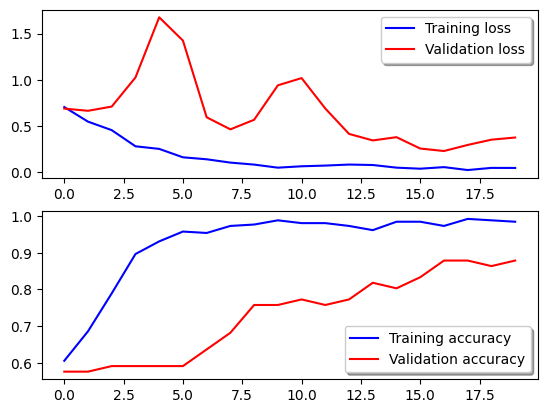

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step
first 10 predictions: [[2.3943526e-03 9.9760562e-01]
 [1.3367408e-03 9.9866331e-01]
 [1.5088195e-06 9.9999839e-01]
 [9.7774589e-01 2.2254076e-02]
 [9.9631864e-01 3.6814464e-03]
 [9.9781013e-01 2.1898921e-03]
 [6.2158144e-01 3.7841862e-01]
 [2.4489611e-01 7.5510389e-01]
 [9.9998730e-01 1.2633785e-05]
 [5.2081760e-02 9.4791824e-01]]
              precision    recall  f1-score   support

     Insects       0.92      0.97      0.94        34
      Plants       0.98      0.94      0.96        48

    accuracy                           0.95        82
   macro avg       0.95      0.95      0.95        82
weighted avg       0.95      0.95      0.95        82



In [16]:
''' 
This cell This code performs a series of tasks to train a machine learning model using different batch 
sizes, evaluate its performance, plot the results, 
make predictions, and log the results using MLflow. 
'''
print("Number of unique classes in y_train:", len(np.unique(y_train)))
print("Number of unique classes in y_valid:", len(np.unique(y_valid)))
print("Number of unique class es in y_test:", len(np.unique(y_test)))

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(np.argmax(y_train, axis=1)), y=np.argmax(y_train, axis=1))
class_weight= dict(enumerate(class_weights))
print("Class weights:", class_weight)
for idx, batch_size in enumerate([16]): #8, 16, 32, 64, 128
    # steps_per_epoch = int(np.ceil(len(x_train) / batch_size)) 
    # print(f"debug! steps_per_epoch: {steps_per_epoch}, len(x_train): {len(x_train)}, batch_size: {batch_size}")
    history = model.fit(
        train_datagen.flow(x_train, y_train, batch_size=batch_size),
        epochs=n_epoch,
        callbacks=[reduce_lr], #early_stop
        validation_data=(x_valid, y_valid),
        # steps_per_epoch=len(x_train) // batch_size  # Adjusted to match the batch size,
        # steps_per_epoch=steps_per_epoch,  # Adjusted to match the batch size,
    # )
        class_weight=class_weight)
    
    # Plotting the results on Graph
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(history.history['loss'], color='b', label="Training loss")
    ax[0].plot(history.history['val_loss'], color='r', label="Validation loss")
    ax[0].legend(loc='best', shadow=True)
    
    ax[1].plot(history.history['categorical_accuracy'], color='b', label="Training accuracy")
    ax[1].plot(history.history['val_categorical_accuracy'], color='r', label="Validation accuracy")
    ax[1].legend(loc='best', shadow=True)
    
    plt.show()  # Ensure the plot displays within each iteration

    # Predictions
    predictions_model = model.predict(x_test)
    print(f"first 10 predictions: {predictions_model[:10]}")
    predictions_model_max = np.argmax(predictions_model, axis=1)
    num_classes = len(np.unique(y_test))  # Ensure correct number of classes
    y_test_int = np.argmax(y_test, axis=1) #convert back to categorical
    print(classification_report(y_test_int, predictions_model_max, target_names=['Insects', 'Plants']))
    # predictions_onehot = to_categorical(predictions_model_max, num_classes=num_classes)
    # accuracy = accuracy_score(y_test, predictions_onehot)
    # accuracy = accuracy_score(y_test, y_test_int)

    
   



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.4394903..3.659168].


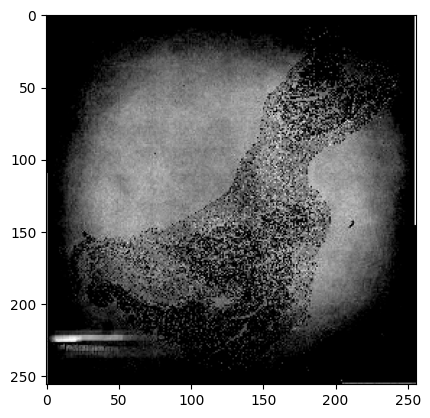

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.473969..1.7312933].


Prediction: [[0.00239435 0.99760556]]
Argmax Prediction: 1
True Label: 1


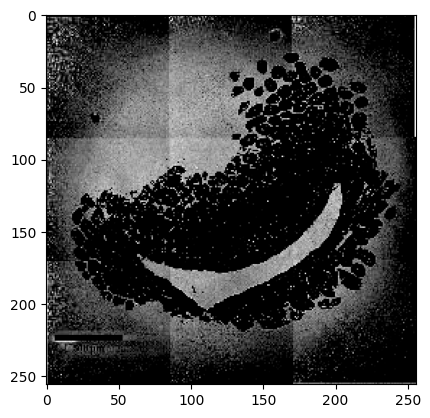

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-12.1273..1.6128072].


Prediction: [[0.00133674 0.9986633 ]]
Argmax Prediction: 1
True Label: 1


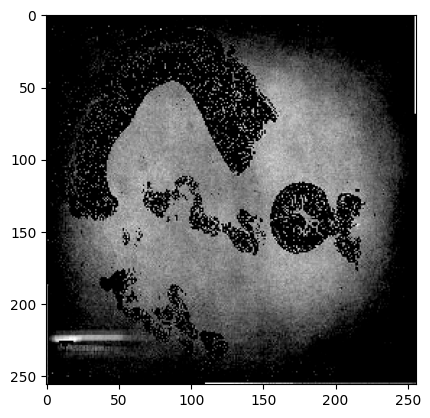

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1294684..1.659609].


Prediction: [[1.5088209e-06 9.9999845e-01]]
Argmax Prediction: 1
True Label: 1


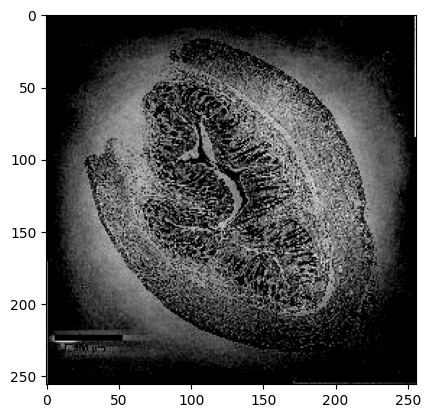

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.674192..4.855906].


Prediction: [[0.9777459  0.02225407]]
Argmax Prediction: 0
True Label: 0


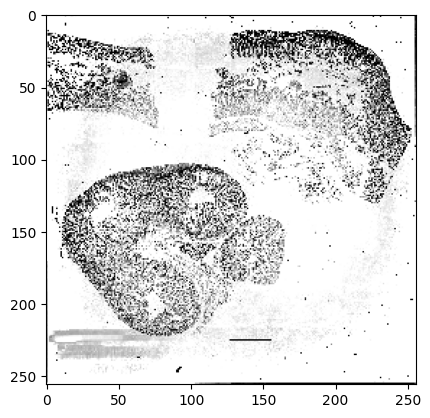

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.990683..5.142694].


Prediction: [[0.9963186  0.00368144]]
Argmax Prediction: 0
True Label: 0


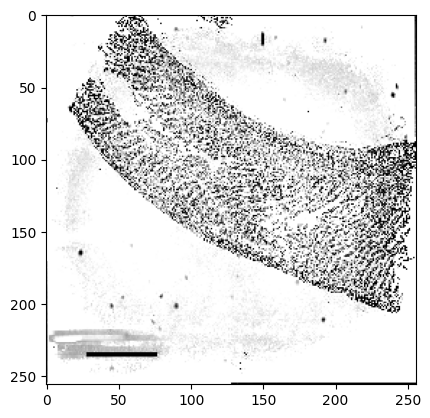

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.715392..1.357231].


Prediction: [[0.9978102  0.00218989]]
Argmax Prediction: 0
True Label: 0


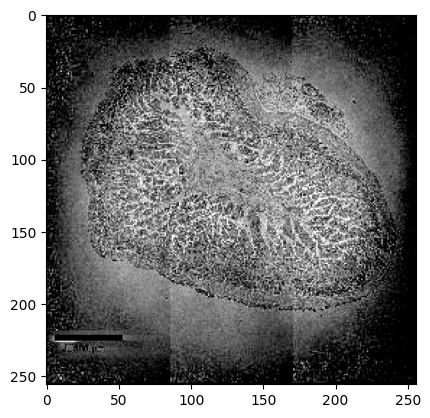

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-11.686278..1.5653669].


Prediction: [[0.62158144 0.37841862]]
Argmax Prediction: 0
True Label: 0


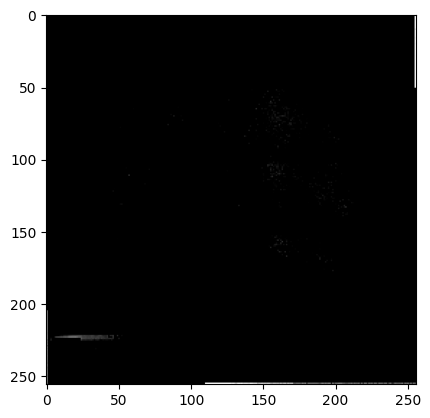

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.6150923..1.3780265].


Prediction: [[0.2448959  0.75510406]]
Argmax Prediction: 1
True Label: 1


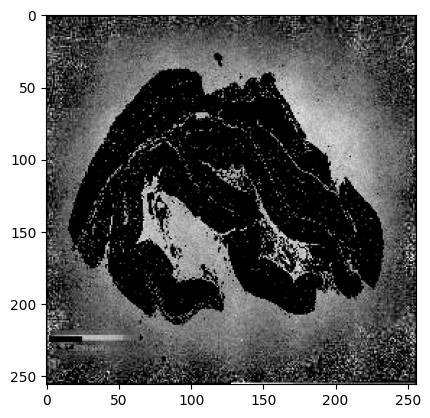

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.1540565..1.1915461].


Prediction: [[9.9998736e-01 1.2633785e-05]]
Argmax Prediction: 0
True Label: 0


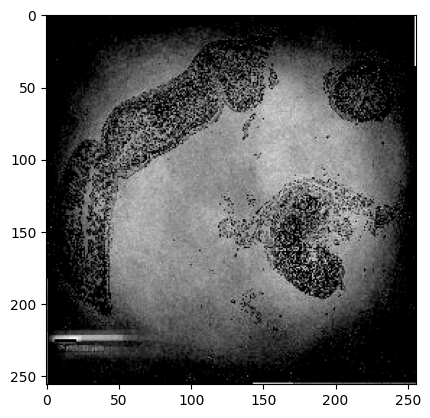

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Prediction: [[0.05208169 0.94791836]]
Argmax Prediction: 1
True Label: 1


In [17]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.imshow(x_test[i])  # Show image
    plt.show()
    pred = model.predict(np.expand_dims(x_test[i], axis=0))
    print("Prediction:", pred)
    print("Argmax Prediction:", np.argmax(pred))
    print("True Label:", np.argmax(y_test[i]))

In [18]:
 # # print(classification_report(y_test, predictions_onehot, target_names=['Insects', 'Plants']))

    # # Start MLflow
    # RUN_NAME = f"run_{idx}"
    # with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=RUN_NAME) as run:
    #     # Retrieve run id
    #     RUN_ID = run.info.run_id
    #     env_Latest_RUN_ID = RUN_ID
    #     print(f"MLflow run ID: {RUN_ID}")
    #     # Track parameters
    #     mlflow.log_param("batch_size", batch_size)
    #     mlflow.log_param("epochs", 60)
    #     mlflow.log_param("image_size", 256)

    #     # Track model
    #     mlflow.sklearn.log_model(model, "Bat_guts_IVP_classifier")

    #     # Track confusion matrix results
    #     mlflow.log_metric("accuracy", accuracy)
    #     mlflow.log_metric('Weighted Precision', precision_score(y_test, predictions_onehot, average='weighted'))
    #     mlflow.log_metric('Weighted Recall', recall_score(y_test, predictions_onehot, average='weighted'))
    #     mlflow.log_metric('Weighted F1-score', f1_score(y_test, predictions_onehot, average='weighted'))
